In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [2]:
import pandas as pd 

In [3]:
data = pd.read_csv(r"/home/ronodeep/thesisfinal-1/all_images_mapping_with_types.csv")

In [4]:
data.head()

,Case Number,Original Filename,Original Path,New Filename,Image Type
0,1,AAAW3.jpg,Case 001/AAAW3.jpg,AAAW3.jpg,After acetic acid
1,1,AAAW2.jpg,Case 001/AAAW2.jpg,AAAW2.jpg,After acetic acid with green filter
2,1,AAAW1.jpg,Case 001/AAAW1.jpg,AAAW1.jpg,After normal saline
3,1,AAAW4.jpg,Case 001/AAAW4.jpg,AAAW4.jpg,After Lugol’s iodine
4,2,AADE4.jpg,Case 002/AADE4.jpg,AADE4.jpg,After Lugol’s iodine


In [5]:
data = data.dropna(axis=1)

In [6]:
data.head()

,Case Number,Original Filename,Original Path,New Filename,Image Type
0,1,AAAW3.jpg,Case 001/AAAW3.jpg,AAAW3.jpg,After acetic acid
1,1,AAAW2.jpg,Case 001/AAAW2.jpg,AAAW2.jpg,After acetic acid with green filter
2,1,AAAW1.jpg,Case 001/AAAW1.jpg,AAAW1.jpg,After normal saline
3,1,AAAW4.jpg,Case 001/AAAW4.jpg,AAAW4.jpg,After Lugol’s iodine
4,2,AADE4.jpg,Case 002/AADE4.jpg,AADE4.jpg,After Lugol’s iodine


In [7]:
data = data.drop(columns=["Case Number"])

In [8]:
data.head()

,Original Filename,Original Path,New Filename,Image Type
0,AAAW3.jpg,Case 001/AAAW3.jpg,AAAW3.jpg,After acetic acid
1,AAAW2.jpg,Case 001/AAAW2.jpg,AAAW2.jpg,After acetic acid with green filter
2,AAAW1.jpg,Case 001/AAAW1.jpg,AAAW1.jpg,After normal saline
3,AAAW4.jpg,Case 001/AAAW4.jpg,AAAW4.jpg,After Lugol’s iodine
4,AADE4.jpg,Case 002/AADE4.jpg,AADE4.jpg,After Lugol’s iodine


In [9]:
data = data.drop(columns=["Original Filename"])

In [10]:
data = data.drop(columns=["Original Path"])

In [11]:
data.head()

,New Filename,Image Type
0,AAAW3.jpg,After acetic acid
1,AAAW2.jpg,After acetic acid with green filter
2,AAAW1.jpg,After normal saline
3,AAAW4.jpg,After Lugol’s iodine
4,AADE4.jpg,After Lugol’s iodine


In [12]:
# Load the dataset with image types
df = pd.read_csv("all_images_mapping_with_types.csv")

# Print the number of unique values for each column
for column in df.columns:
    unique_count = df[column].nunique()
    print(f"{column}: {unique_count} unique values")

# Get the unique image types and their counts
print("\nUnique Image Types:")
image_types = df['Image Type'].value_counts()
print(image_types)

# Total number of unique filenames
print(f"\nTotal unique image files: {df['New Filename'].nunique()}")

Case Number: 200 unique values
Original Filename: 913 unique values
Original Path: 913 unique values
New Filename: 913 unique values
Image Type: 24 unique values

Unique Image Types:
Image Type
After acetic acid                                                  293
After Lugol’s iodine                                               153
After normal saline                                                151
After normal saline with green filter                               91
After acetic acid with green filter                                 80
Speculum examination                                                72
After acetic acid with higher magnification                         23
Visualization of the SCJ                                            15
Unknown                                                              9
Examination with endocervical speculum                               7
After acetic acid with endocervical speculum                         3
After acetic acid        

In [13]:
unique_values = data['Image Type'].unique()
print(unique_values)

['After acetic acid' 'After acetic acid with green filter'
 'After normal saline' 'After Lugol’s iodine' 'Speculum examination'
 'After normal saline with green filter'
 'After acetic acid with higher magnification' 'Unknown'
 'After acetic acid with endocervical speculum'
 'Examination with endocervical speculum' 'Visualization of the SCJ'
 'After normal saline with higher magnification'
 'Before speculum examination' 'Examination of endocervical canal'
 'Examination of endocervix' 'After Lugol’s iodine '
 'After acetic acid and pushing the polyp inside' 'After acetic acid '
 'Vulva before acetic acid' 'Vulva after acetic acid'
 'After normal saline with green filter with higher magnification'
 'Speculum examination with higher magnification'
 'Examination of the vagina' 'Examination of the vulva']


In [14]:
import numpy as np
for i in unique_values:
    print(i, np.where(unique_values==i)[0][0])

After acetic acid 0
After acetic acid with green filter 1
After normal saline 2
After Lugol’s iodine 3
Speculum examination 4
After normal saline with green filter 5
After acetic acid with higher magnification 6
Unknown 7
After acetic acid with endocervical speculum 8
Examination with endocervical speculum 9
Visualization of the SCJ 10
After normal saline with higher magnification 11
Before speculum examination 12
Examination of endocervical canal 13
Examination of endocervix 14
After Lugol’s iodine  15
After acetic acid and pushing the polyp inside 16
After acetic acid  17
Vulva before acetic acid 18
Vulva after acetic acid 19
After normal saline with green filter with higher magnification 20
Speculum examination with higher magnification 21
Examination of the vagina 22
Examination of the vulva 23


In [15]:
# Install required packages
#%pip install torch torchvision scikit-image networkx torch-geometric tqdm

In [16]:
import torch.multiprocessing
torch.multiprocessing.set_start_method('spawn', force=True)
# All imports must be at the top level of your notebook
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.segmentation import slic
from skimage.color import rgb2lab
from skimage.measure import regionprops
from skimage.util import img_as_float
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torchvision import models, transforms
from tqdm import tqdm
import time
import torch.serialization
from torch_geometric.data.data import DataEdgeAttr

In [17]:
# Define the pre-trained model for feature extraction
def get_feature_extractor():
    # Use weights parameter instead of pretrained
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Remove the final fully connected layer
    feature_extractor = nn.Sequential(*list(model.children())[:-2])
    feature_extractor.eval()  # Set to evaluation mode
    return feature_extractor

# Image preprocessing for the CNN
def preprocess_image(img):
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return preprocess(img).unsqueeze(0)  # Add batch dimension

# Function to extract superpixel and deep learning features
def extract_combined_features(image_path, feature_extractor, device, n_segments=100):
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image at {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Generate superpixels
    segments = slic(img_as_float(img), n_segments=n_segments, compactness=10, sigma=1)
    
    # Get deep features from pre-trained model
    input_tensor = preprocess_image(img)
    input_tensor = input_tensor.to(device)
    
    with torch.no_grad():
        feature_maps = feature_extractor(input_tensor)
    
    # Feature maps shape: [1, channels, height, width]
    # Resize to match original image dimensions for easier mapping
    feature_maps = F.interpolate(feature_maps, size=(img.shape[0], img.shape[1]), 
                                mode='bilinear', align_corners=False)
    feature_maps = feature_maps.squeeze(0)  # Remove batch dimension
    feature_maps = feature_maps.permute(1, 2, 0)  # [H, W, C]
    feature_maps = feature_maps.cpu().numpy()
    
    # Convert image to LAB for color features
    img_lab = rgb2lab(img)
    
    # Extract features for each superpixel
    superpixel_features = []
    
    for segment_id in np.unique(segments):
        # Create mask for this superpixel
        mask = segments == segment_id
        
        # 1. Deep learning features from feature maps
        deep_features = feature_maps[mask].mean(axis=0)
        
        # 2. Traditional color features
        rgb_mean = img[mask].mean(axis=0)
        rgb_std = img[mask].std(axis=0)
        lab_mean = img_lab[mask].mean(axis=0)
        lab_std = img_lab[mask].std(axis=0)
        
        # 3. Shape features
        props = regionprops(mask.astype(int))[0]
        area = props.area
        perimeter = props.perimeter
        if perimeter > 0:
            circularity = 4 * np.pi * area / (perimeter ** 2)
        else:
            circularity = 0
        
        # Reduce dimensionality of deep features using PCA or taking subset
        # For simplicity, we'll take the first 16 features
        if len(deep_features) > 16:
            deep_features = deep_features[:16]
        
        # Combine all features
        combined_features = np.concatenate([
            deep_features,
            rgb_mean, rgb_std, 
            lab_mean, lab_std,
            [area, perimeter, circularity]
        ])
        
        superpixel_features.append(combined_features)
    
    return np.array(superpixel_features), segments

In [18]:
def are_adjacent(segments, id1, id2):
    """Check if two superpixels are adjacent"""
    # Create boundary pixels for both segments
    mask1 = segments == id1
    mask2 = segments == id2
    
    # Dilate masks to find overlapping boundaries
    kernel = np.ones((3, 3), np.uint8)
    dilated1 = cv2.dilate(mask1.astype(np.uint8), kernel, iterations=1)
    
    # If dilated mask of segment1 overlaps with segment2, they are adjacent
    return np.any(dilated1 & mask2)

def build_graph(image_path, feature_extractor, device, n_segments=100):
    """Build a graph from superpixels in an image"""
    try:
        superpixel_features, segments = extract_combined_features(
            image_path, feature_extractor, device, n_segments)
        
        # Create a graph where nodes are superpixels
        G = nx.Graph()
        
        # Add nodes with features
        for idx, features in enumerate(superpixel_features):
            G.add_node(idx, features=features)
        
        # Add edges based on adjacency
        for i in range(len(superpixel_features)):
            for j in range(i+1, len(superpixel_features)):
                if are_adjacent(segments, i, j):
                    G.add_edge(i, j)
        
        # Convert to PyTorch Geometric data
        node_features = torch.tensor([G.nodes[i]['features'] for i in G.nodes], dtype=torch.float)
        
        # Create edge index tensor
        if len(G.edges) > 0:
            edge_index = torch.tensor(list(G.edges)).t().contiguous()
            # Add reverse edges for undirected graph
            edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
        else:
            # Handle case with no edges
            edge_index = torch.zeros((2, 0), dtype=torch.long)
        
        return Data(x=node_features, edge_index=edge_index), segments
    except Exception as e:
        print(f"Error building graph for {image_path}: {e}")
        # Return a dummy graph
        return None, None

In [19]:
def visualize_superpixels(image_path, segments):
    """Visualize superpixel segmentation"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Create a figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # Display original image
    ax1.imshow(img)
    ax1.set_title('Original Image')
    ax1.axis('off')
    
    # Mark boundaries of segments on a copy of the image
    from skimage.segmentation import mark_boundaries
    marked_img = mark_boundaries(img, segments)
    ax2.imshow(marked_img)
    ax2.set_title(f'Superpixel Segmentation (n={len(np.unique(segments))})')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_graph(G, segments, image_path):
    """Visualize graph structure over superpixels"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Calculate centroids of superpixels for node positions
    centroids = {}
    for segment_id in np.unique(segments):
        mask = segments == segment_id
        props = regionprops(mask.astype(int))[0]
        centroids[segment_id] = props.centroid
    
    # Create a figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # Display original image with superpixel boundaries
    from skimage.segmentation import mark_boundaries
    marked_img = mark_boundaries(img, segments)
    ax1.imshow(marked_img)
    ax1.set_title('Superpixels')
    ax1.axis('off')
    
    # Display graph over image
    ax2.imshow(img, alpha=0.7)
    
    # Draw nodes (superpixel centroids)
    pos = {i: (centroids[i][1], centroids[i][0]) for i in range(len(centroids))}
    nx.draw_networkx_nodes(G, pos, node_size=20, node_color='red', ax=ax2)
    nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.7, ax=ax2)
    
    ax2.set_title(f'Graph ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

In [20]:
# Put this before defining your CervicalImageDataset class


# Make your class serializable
from torch.utils.data import Dataset

class CervicalImageDataset(Dataset):
    # Keep the rest of your class the same
    
    # Make the class picklable
    def __reduce__(self):
        return (self.__class__, (self.image_df, self.img_dir, self.feature_extractor, 
                                self.device, self.n_segments, self.cache_dir))
        
class CervicalImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_df, img_dir, feature_extractor, device, n_segments=50, cache_dir=None):
        self.image_df = image_df
        self.img_dir = img_dir
        self.n_segments = n_segments
        self.feature_extractor = feature_extractor
        self.device = device
        self.cache_dir = cache_dir
        
        # Create mapping for image types to numeric values
        self.type_mapping = {t: i for i, t in enumerate(image_df['Image Type'].unique())}
        print(f"Created dataset with {len(self.type_mapping)} classes")
        
        # If cache directory is provided, create it if it doesn't exist
        if cache_dir:
            os.makedirs(cache_dir, exist_ok=True)
            
    def __len__(self):
        return len(self.image_df)
    
    def __getitem__(self, idx):
        row = self.image_df.iloc[idx]
        image_path = os.path.join(self.img_dir, row['New Filename'])
        
        # Check if graph is cached
        if self.cache_dir:
            cache_path = os.path.join(self.cache_dir, f"{row['New Filename']}.pt")
            if os.path.exists(cache_path):
                try:
                    # Use safe_globals without local imports
                    with torch.serialization.safe_globals([DataEdgeAttr]):
                        data = torch.load(cache_path, weights_only=False)
                    return data
                except Exception as e:
                    print(f"Error loading cached graph {cache_path}: {e}")
                    # If loading fails, delete the corrupt cache file and regenerate
                    try:
                        os.remove(cache_path)
                        print(f"Deleted corrupt cache file: {cache_path}")
                    except:
                        pass
        
        # Build graph from image
        try:
            graph, segments = build_graph(
                image_path, self.feature_extractor, self.device, self.n_segments)
            
            if graph is None:
                raise ValueError("Graph construction failed")
                
            # Add image type as graph-level feature
            type_idx = self.type_mapping[row['Image Type']]
            graph.y = torch.tensor([type_idx], dtype=torch.long)
            
            # Add case number for reference
            graph.case_num = row['Case Number']
            
            # Cache the graph if cache_dir is provided
            if self.cache_dir:
                torch.save(graph, cache_path)
                
            return graph
        except Exception as e:
            print(f"Error processing image {row['New Filename']}: {e}")
            # Create a minimal valid graph
            x = torch.zeros((1, 31), dtype=torch.float)
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            dummy_graph = Data(x=x, edge_index=edge_index)
            dummy_graph.y = torch.tensor([0], dtype=torch.long)
            dummy_graph.case_num = row['Case Number']
            return dummy_graph

In [21]:
def preprocess_all_graphs(dataset, desc="Processing"):
    all_graphs = []
    for i in tqdm(range(len(dataset)), desc=desc):
        try:
            graph = dataset[i]
            if graph is not None and hasattr(graph, 'y'):  # Make sure the graph has expected attributes
                all_graphs.append(graph)
        except Exception as e:
            print(f"Error processing item {i}: {e}")
    return all_graphs

In [22]:
class CervicalImageGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, dropout_rate=0.5):
        super().__init__()
        self.dropout_rate = dropout_rate
        
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3 = torch.nn.BatchNorm1d(hidden_channels)
        self.linear = torch.nn.Linear(hidden_channels, num_classes)
        
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # If batch isn't provided (for single graphs), create it
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        
        # Graph convolutions with batch normalization for faster training
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        # Global pooling
        x = global_mean_pool(x, batch)
        
        # Classification layer
        x = self.linear(x)
        
        return F.log_softmax(x, dim=1)

In [23]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize the feature extractor
feature_extractor = get_feature_extractor().to(device)
print("Initialized pre-trained ResNet18 feature extractor")

# Load your dataset
df = pd.read_csv("all_images_mapping_with_types.csv")
print(f"Loaded dataset with {len(df)} images")

# Create a directory for caching graphs
cache_dir = "cached_graphs"
os.makedirs(cache_dir, exist_ok=True)

# Test the feature extraction on a sample image
sample_row = df.iloc[0]  # First image
sample_path = os.path.join('all_colposcopy_images', sample_row['New Filename'])
print(f"Testing feature extraction on {sample_path}")

# Create a small sample dataset for testing
sample_size = 50  # Adjust based on your needs
sample_df = df.sample(sample_size) if len(df) > sample_size else df

# Process sample images
dataset = CervicalImageDataset(
    image_df=sample_df,
    img_dir='all_colposcopy_images',
    feature_extractor=feature_extractor,
    device=device,
    n_segments=50,
    cache_dir=cache_dir
)

print("Preprocessing and caching sample graphs...")
preprocessed_graphs = preprocess_all_graphs(dataset, "Sample processing")
print(f"Successfully processed {len(preprocessed_graphs)} graphs")

# Show details of the first few graphs
for i in range(min(5, len(preprocessed_graphs))):
    graph = preprocessed_graphs[i]
    print(f"Graph {i+1}:")
    print(f"  Nodes: {graph.num_nodes}, Edges: {graph.num_edges}")
    print(f"  Feature dimensions: {graph.x.shape}")
    print(f"  Class label: {graph.y.item()}")
    print()

# Now process all images (uncomment when ready)

print("Processing all images...")
full_dataset = CervicalImageDataset(
    image_df=df,
    img_dir='all_colposcopy_images',
    feature_extractor=feature_extractor,
    device=device,
    n_segments=50,
    cache_dir=cache_dir
)

# Process all graphs one by one
print("Preprocessing and caching all graphs...")
all_graphs = preprocess_all_graphs(full_dataset, "Full processing")
print(f"Successfully processed {len(all_graphs)} graphs")

# Create a loader for preprocessing
# Use the preprocess_all_graphs function that already works
print("Preprocessing and caching all graphs...")
all_graphs = preprocess_all_graphs(full_dataset, "Full processing")

print(f"Successfully processed {len(all_graphs)} graphs")


Using device: cuda
Initialized pre-trained ResNet18 feature extractor
Loaded dataset with 913 images
Testing feature extraction on all_colposcopy_images/AAAW3.jpg
Created dataset with 9 classes
Preprocessing and caching sample graphs...


Sample processing: 100%|██████████| 50/50 [00:00<00:00, 5043.66it/s]


Successfully processed 50 graphs
Graph 1:
  Nodes: 33, Edges: 148
  Feature dimensions: torch.Size([33, 31])
  Class label: 19

Graph 2:
  Nodes: 44, Edges: 222
  Feature dimensions: torch.Size([44, 31])
  Class label: 5

Graph 3:
  Nodes: 35, Edges: 164
  Feature dimensions: torch.Size([35, 31])
  Class label: 3

Graph 4:
  Nodes: 48, Edges: 236
  Feature dimensions: torch.Size([48, 31])
  Class label: 5

Graph 5:
  Nodes: 40, Edges: 194
  Feature dimensions: torch.Size([40, 31])
  Class label: 2

Processing all images...
Created dataset with 24 classes
Preprocessing and caching all graphs...


Full processing: 100%|██████████| 913/913 [00:00<00:00, 6949.66it/s]


Successfully processed 913 graphs
Preprocessing and caching all graphs...


Full processing: 100%|██████████| 913/913 [00:00<00:00, 6792.40it/s]

Successfully processed 913 graphs


In [24]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    progress_bar = tqdm(loader, desc="Training")
    for data in progress_bar:
        # Move to device
        data = data.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        out = model(data)
        
        # Safety check - clamp labels to valid range
        if data.y.min() < 0 or data.y.max() >= out.shape[1]:
            print(f"WARNING: Clamping labels from {data.y.tolist()} to range [0, {out.shape[1]-1}]")
            data.y = torch.clamp(data.y, 0, out.shape[1]-1)
        
        # Compute loss
        loss = criterion(out, data.y)
        
        # Optional L2 regularization
        l2_reg = 0.0
        for param in model.parameters():
            l2_reg += torch.norm(param, 2)
        loss += 1e-4 * l2_reg
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    return total_loss / len(loader.dataset)

def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data in loader:
            try:
                # Move to device
                data = data.to(device)
                
                # Forward pass
                out = model(data)
                
                # Safety check - clamp labels
                if data.y.min() < 0 or data.y.max() >= out.shape[1]:
                    data.y = torch.clamp(data.y, 0, out.shape[1]-1)
                    
                # Get predictions
                pred = out.argmax(dim=1)
                correct += int((pred == data.y).sum())
                total += data.y.size(0)
            except Exception as e:
                print(f"Error during evaluation: {e}")
                print(f"Data object keys: {data.keys}")
                continue
    
    return correct / total if total > 0 else 0.0

# Create cached dataset
class CachedGraphDataset(torch.utils.data.Dataset):
    def __init__(self, graphs):
        self.graphs = graphs
    
    def __len__(self):
        return len(self.graphs)
    
    def __getitem__(self, idx):
        return self.graphs[idx]

# Instead of splitting into train/val/test, use cross-validation
from sklearn.model_selection import KFold

# Define features and classes
if len(preprocessed_graphs) > 0:
    num_features = preprocessed_graphs[0].num_node_features
    # Get the unique classes
    all_labels = [graph.y.item() for graph in preprocessed_graphs]
    num_classes = len(set(all_labels))
    print(f"Dataset has {num_features} features and {num_classes} classes")
else:
    print("Error: No preprocessed graphs available")
# Add this before the cross-validation code
# Check and fix target labels
# Check and remap labels to ensure they are in a valid range
all_labels = []
for graph in preprocessed_graphs:
    all_labels.append(graph.y.item())

unique_labels = sorted(set(all_labels))
print(f"Found {len(unique_labels)} unique labels: {unique_labels}")

# Create a mapping from current labels to sequential indices starting from 0
label_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
print(f"Label mapping: {label_map}")

# Apply the mapping to all graphs
for graph in preprocessed_graphs:
    old_label = graph.y.item()
    new_label = label_map[old_label]
    graph.y = torch.tensor([new_label], dtype=torch.long)
    

# Update the number of classes
num_classes = len(unique_labels)
print(f"Updated number of classes: {num_classes}")

# Verify the remapping worked
verified_labels = [graph.y.item() for graph in preprocessed_graphs]
verified_unique = sorted(set(verified_labels))
print(f"Verified unique labels after remapping: {verified_unique}")
    
# Use fixed_graphs instead of preprocessed_graphs for cross-validation

# K-fold cross-validation
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
all_test_accs = []

# Use all available data
all_data = preprocessed_graphs

for fold, (train_idx, test_idx) in enumerate(kf.split(all_data)):
    print(f"Fold {fold+1}/{k_folds}")
    
    # Create train/val/test split for this fold
    train_val_data = [all_data[i] for i in train_idx]
    test_data = [all_data[i] for i in test_idx]
    
    # Further split train into train/val
    val_size = int(0.2 * len(train_val_data))
    train_data = train_val_data[val_size:]
    val_data = train_val_data[:val_size]
    
    print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")
    
    # Create dataloaders
    train_loader = PyGDataLoader(train_data, batch_size=16, shuffle=True)
    val_loader = PyGDataLoader(val_data, batch_size=16)
    test_loader = PyGDataLoader(test_data, batch_size=16)
    
    # Initialize a new model for this fold
    # Reset the model or create a new one
    model = CervicalImageGNN(
    in_channels=num_features,
    hidden_channels=64,
    num_classes=num_classes,
    dropout_rate=0.3
    ).to(device)

    # Setup optimizer with explicit learning rate
    initial_lr = 0.003
    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr, weight_decay=0.0001)

    # Use Cosine Annealing with Warm Restarts for better learning rate scheduling
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=5,       # Restart every 5 epochs
        T_mult= 1,     # Keep restart frequency constant
        eta_min=1e-6  # Minimum learning rate
    )

    # Print the initial learning rate
    print(f"Initial learning rate: {optimizer.param_groups[0]['lr']}")
    
    criterion = torch.nn.NLLLoss()
    
    # Train model for this fold
    best_val_acc = 0
    best_model = model.state_dict().copy()
    
    for epoch in range(30):  # Reduced epochs
        train_loss = train(model, train_loader, optimizer, criterion, device)
        train_acc = evaluate(model, train_loader, device)
        val_acc = evaluate(model, val_loader, device)
        
        # Step the scheduler every epoch (not based on performance)
        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model.state_dict().copy()
        
        print(f'Fold {fold+1}, Epoch {epoch}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, LR: {current_lr:.6f}')
    
    # Evaluate on test set
    model.load_state_dict(best_model)
    test_acc = evaluate(model, test_loader, device)
    all_test_accs.append(test_acc)
    print(f'Fold {fold+1} Test Accuracy: {test_acc:.4f}\n')

# Final results
print(f"Cross-validation test accuracies: {all_test_accs}")
print(f"Average test accuracy: {sum(all_test_accs)/len(all_test_accs):.4f}")

Dataset has 31 features and 9 classes
Found 9 unique labels: [0, 1, 2, 3, 4, 5, 10, 17, 19]
Label mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 10: 6, 17: 7, 19: 8}
Updated number of classes: 9
Verified unique labels after remapping: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Fold 1/5
Train: 32, Val: 8, Test: 10
Initial learning rate: 0.003


Training:  50%|█████     | 1/2 [00:00<00:00,  3.58it/s, loss=2.22]


KeyError: 'num_segments'

Initial learning rate: 0.003


Training: 100%|██████████| 2/2 [00:00<00:00, 57.47it/s, loss=2.31]


Epoch: 000, Loss: 2.3497, Train Acc: 0.1562, Val Acc: 0.0000, Test Acc: 0.2000, LR: 0.003000


Training: 100%|██████████| 2/2 [00:00<00:00, 74.90it/s, loss=2.18]


New best validation accuracy: 0.1250
Epoch: 001, Loss: 2.2163, Train Acc: 0.1875, Val Acc: 0.1250, Test Acc: 0.4000, LR: 0.003000


...

Epoch: 130, Loss: 0.1729, Train Acc: 0.4688, Val Acc: 0.1250, Test Acc: 0.1000, LR: 0.000287


Training: 100%|██████████| 2/2 [00:00<00:00, 52.60it/s, loss=0.199]


Epoch: 131, Loss: 0.1973, Train Acc: 0.5312, Val Acc: 0.2500, Test Acc: 0.0000, LR: 0.003000


Training: 100%|██████████| 2/2 [00:00<00:00, 59.79it/s, loss=0.31]


Epoch: 132, Loss: 0.2937, Train Acc: 0.5625, Val Acc: 0.2500, Test Acc: 0.3000, LR: 0.002714
Early stopping at epoch 132 as validation accuracy hasn't improved for 130 epochs
Loaded best model with validation accuracy: 0.3750
Final Test Accuracy: 0.3000


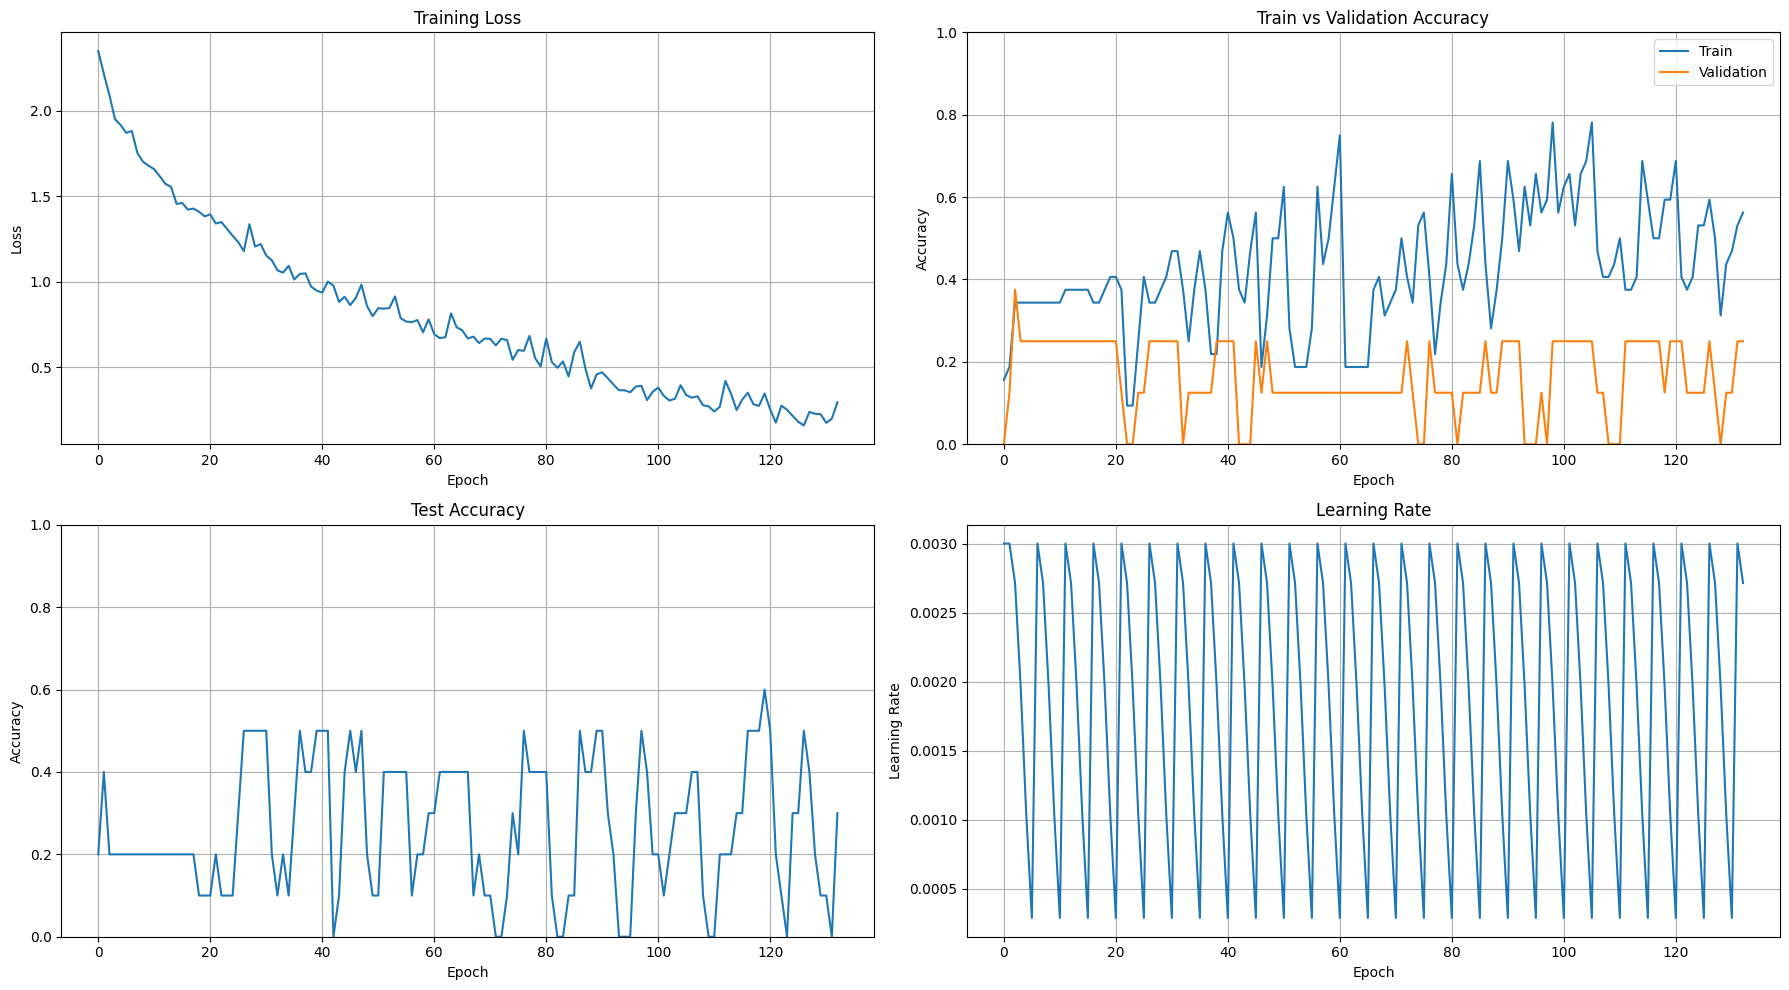

In [25]:
# Train the model
# Reset model and optimizer to ensure clean start
model = CervicalImageGNN(
    in_channels=num_features,
    hidden_channels=64,
    num_classes=num_classes,
    dropout_rate=0.3
).to(device)

# Setup optimizer with explicit learning rate
initial_lr = 0.003
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr, weight_decay=0.0001)

# Use Cosine Annealing with Warm Restarts for better learning rate scheduling
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=5,       # Restart every 10 epochs
    T_mult=1,     # Keep restart frequency constant
    eta_min=1e-6  # Minimum learning rate
)

# Print the initial learning rate
print(f"Initial learning rate: {optimizer.param_groups[0]['lr']}")

# Initialize tracking variables
num_epochs = 150
best_val_acc = 0
patience = 130    # Reasonable patience value
patience_counter = 0
best_model = model.state_dict().copy()
train_losses = []
train_accuracies = []  # Added for tracking training accuracy
val_accuracies = []
test_accuracies = []   # Added for tracking test accuracy each epoch
learning_rates = []    # For tracking LR changes

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = train(model, train_loader, optimizer, criterion, device)
    
    # Evaluation
    model.eval()
    train_acc = evaluate(model, train_loader, device)
    val_acc = evaluate(model, val_loader, device)
    test_acc = evaluate(model, test_loader, device)  # Evaluate on test set each epoch
    
    # Store metrics for plotting
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)  # Store training accuracy
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)    # Store test accuracy
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]["lr"]
    learning_rates.append(current_lr)  # Track for visualization
    
    # Step the scheduler (for CosineAnnealingWarmRestarts pass epoch)
    scheduler.step(epoch)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model.state_dict().copy()
        patience_counter = 0
        print(f"New best validation accuracy: {val_acc:.4f}")
    else:
        patience_counter += 1
        
    print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, 'f'Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}, LR: {current_lr:.6f}')
    
    # Early stopping
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch} as validation accuracy hasn't improved for {patience} epochs")
        break

# Load best model and evaluate on test set
if best_model is not None:
    model.load_state_dict(best_model)
    print(f"Loaded best model with validation accuracy: {best_val_acc:.4f}")
final_test_acc = evaluate(model, test_loader, device)
print(f'Final Test Accuracy: {final_test_acc:.4f}')

# Plot training curves
plt.figure(figsize=(18, 10))

# Plot loss
plt.subplot(2, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Plot training and validation accuracy together
plt.subplot(2, 2, 2)
plt.plot(train_accuracies, label='Train')
plt.plot(val_accuracies, label='Validation')
plt.title('Train vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis from 0 to 1
plt.legend()
plt.grid(True)

# Plot test accuracy
plt.subplot(2, 2, 3)
plt.plot(test_accuracies)
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Set y-axis from 0 to 1
plt.grid(True)

# Plot learning rate
plt.subplot(2, 2, 4)
plt.plot(learning_rates)
plt.title('Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')  # Save the figure in case display doesn't work
plt.show()

In [26]:
# %pip install seaborn
# %pip install scikit-learn

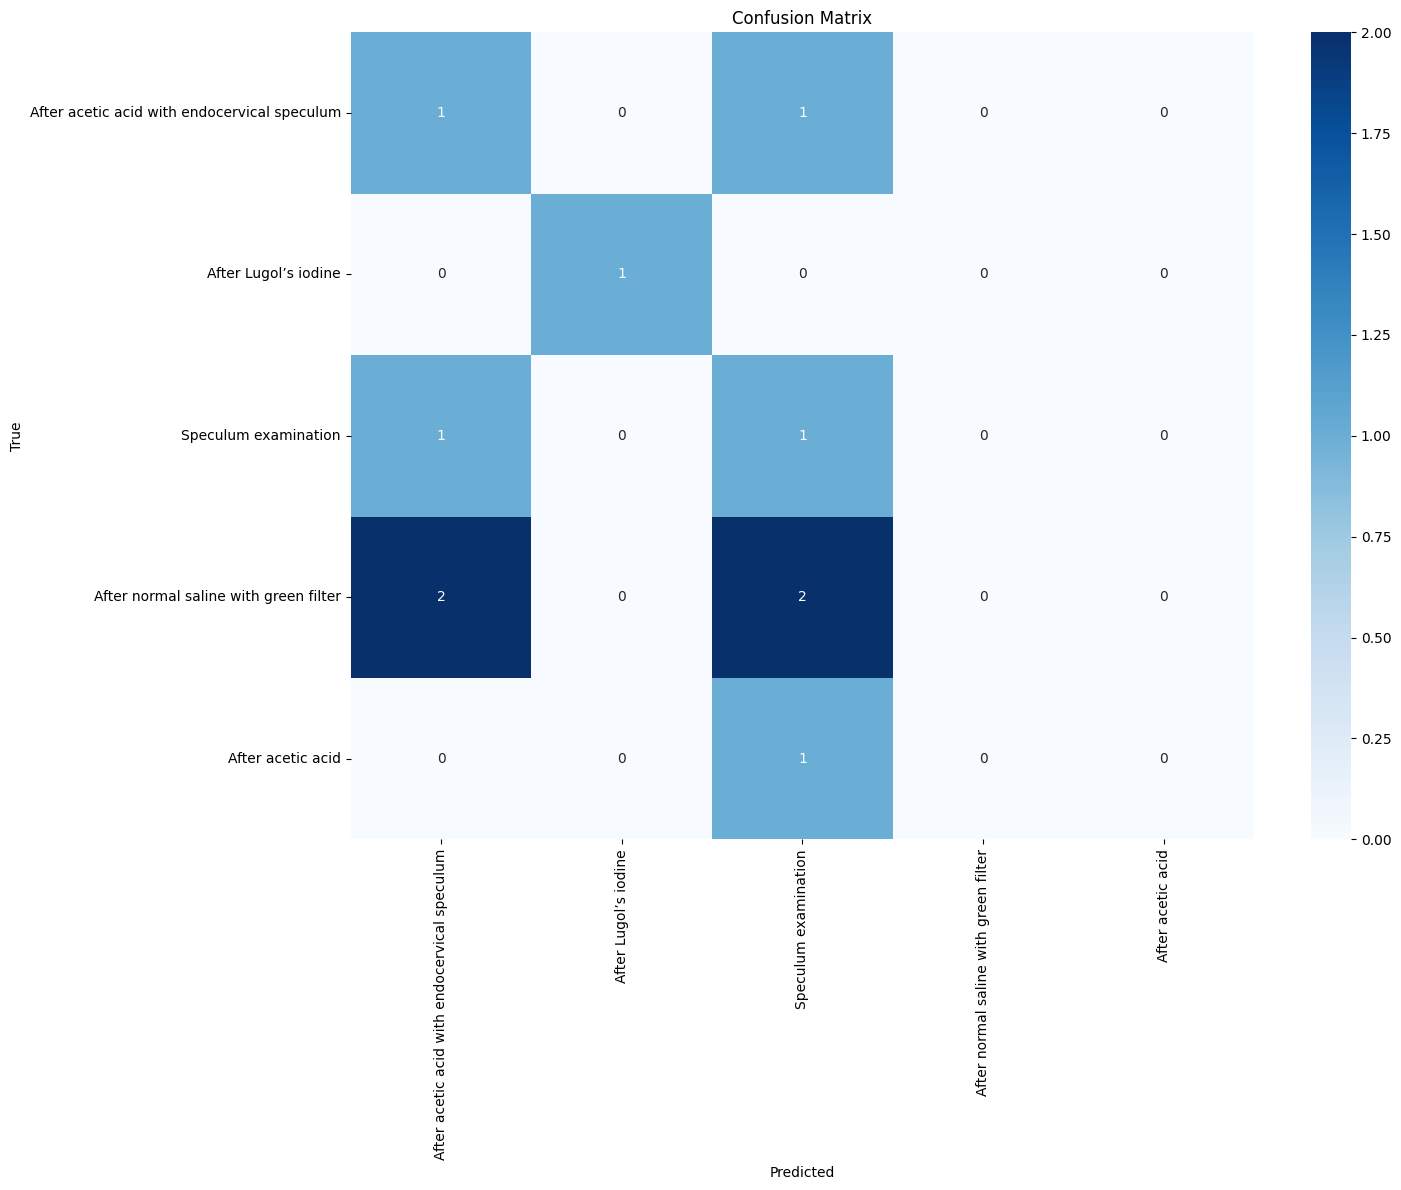

                                              precision    recall  f1-score   support

After acetic acid with endocervical speculum       0.25      0.50      0.33         2
                        After Lugol’s iodine       1.00      1.00      1.00         1
                        Speculum examination       0.20      0.50      0.29         2
       After normal saline with green filter       0.00      0.00      0.00         4
                           After acetic acid       0.00      0.00      0.00         1

                                    accuracy                           0.30        10
                                   macro avg       0.29      0.40      0.32        10
                                weighted avg       0.19      0.30      0.22        10



/home/ronodeep/thesisfinal-1/p3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ronodeep/thesisfinal-1/p3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ronodeep/thesisfinal-1/p3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [27]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import numpy as np

def get_predictions(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            y_true.extend(data.y.cpu().tolist())
            y_pred.extend(pred.cpu().tolist())
    
    return y_true, y_pred

# Get predictions
y_true, y_pred = get_predictions(model, test_loader, device)

# Find unique classes in the predictions and ground truth
unique_classes = np.unique(np.array(y_true + y_pred))

# Create a confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=unique_classes)

# Get class names, but filter them to only include classes that appear in the data
idx_to_type = {idx: class_name for class_name, idx in dataset.type_mapping.items()}
class_names = [idx_to_type[i] for i in unique_classes if i in idx_to_type]

# Plot confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Classification report
print(classification_report(y_true, y_pred, labels=unique_classes, target_names=class_names))

Analyzing importance for image: all_colposcopy_images/AAHU5.jpg


/tmp/ipykernel_21411/2688736466.py:34: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  node_features = torch.tensor([G.nodes[i]['features'] for i in G.nodes], dtype=torch.float)


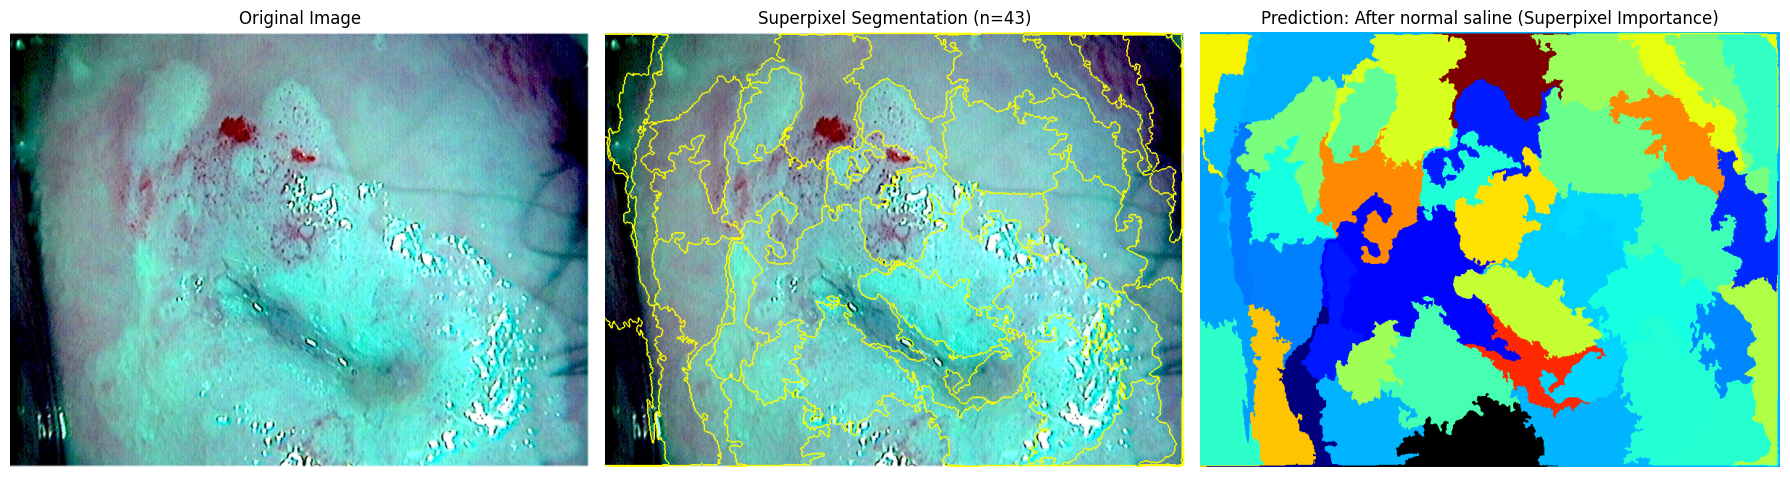

In [28]:
def visualize_important_superpixels(model, image_path, feature_extractor, device, n_segments=50):
    """Visualize which superpixels are most important for classification"""
    # Process image and build graph
    graph, segments = build_graph(image_path, feature_extractor, device, n_segments)
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        graph_data = graph.to(device)
        out = model(graph_data)
        pred_class = out.argmax(dim=1).item()
    
    # Get class name
    idx_to_type = {idx: class_name for class_name, idx in dataset.type_mapping.items()}
    pred_class_name = idx_to_type[pred_class]
    
    # Calculate importance scores for each node (superpixel)
    # We'll use a simple approach: remove each node and see how prediction changes
    importance_scores = []
    
    for node_idx in range(graph.num_nodes):
        # Create a copy of the graph with this node masked
        x_masked = graph.x.clone()
        x_masked[node_idx] = 0  # Zero out the node features
        
        # Create new data object
        masked_data = Data(x=x_masked, edge_index=graph.edge_index)
        masked_data = masked_data.to(device)
        
        # Get prediction for masked graph
        with torch.no_grad():
            out_masked = model(masked_data)
            
        # Calculate change in confidence for the predicted class
        orig_confidence = out[0, pred_class].item()
        masked_confidence = out_masked[0, pred_class].item()
        
        # Importance is how much confidence decreases when node is removed
        importance = orig_confidence - masked_confidence
        importance_scores.append(importance)
    
    # Normalize importance scores to [0, 1]
    importance_scores = np.array(importance_scores)
    importance_scores = (importance_scores - importance_scores.min()) 
    if importance_scores.max() > 0:
        importance_scores = importance_scores / importance_scores.max()
    
    # Visualize the original image with superpixels
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Create a heatmap image
    heat_img = np.zeros_like(img, dtype=np.float32)
    
    # Color each superpixel according to its importance
    for i, score in enumerate(importance_scores):
        mask = segments == i
        # Use a colormap (red = important, blue = not important)
        color = plt.cm.jet(score)[:3]  # Get RGB from colormap
        for c in range(3):
            heat_img[:,:,c][mask] = color[c] * 255
    
    # Create a figure with subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # Display original image
    ax1.imshow(img)
    ax1.set_title('Original Image')
    ax1.axis('off')
    
    # Display superpixel segmentation
    from skimage.segmentation import mark_boundaries
    marked_img = mark_boundaries(img, segments)
    ax2.imshow(marked_img)
    ax2.set_title(f'Superpixel Segmentation (n={len(np.unique(segments))})')
    ax2.axis('off')
    
    # Display importance heatmap
    ax3.imshow(heat_img.astype(np.uint8))
    ax3.set_title(f'Prediction: {pred_class_name} (Superpixel Importance)')
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return importance_scores, segments

# Use this function on some test images
if len(preprocessed_graphs) > 0:
    # Get a test image
    test_idx = 0
    test_graph = preprocessed_graphs[test_idx]
    case_num = test_graph.case_num
    
    # Find the corresponding row in the dataframe
    test_row = df[df['Case Number'] == case_num].iloc[0]
    test_path = os.path.join('all_colposcopy_images', test_row['New Filename'])
    
    print(f"Analyzing importance for image: {test_path}")
    importance_scores, segments = visualize_important_superpixels(
        model, test_path, feature_extractor, device)

In [29]:
# Save the trained model
torch.save({
    'model_state_dict': best_model,
    'optimizer_state_dict': optimizer.state_dict(),
    'feature_dims': num_features,
    'num_classes': num_classes,
    'type_mapping': dataset.type_mapping
}, 'cervical_cancer_gnn_model.pt')

print("Model saved to cervical_cancer_gnn_model.pt")

# Function to load the model (for future use)
def load_model(model_path, device):
    checkpoint = torch.load(model_path, map_location=device)
    
    model = CervicalImageGNN(
        in_channels=checkpoint['feature_dims'],
        hidden_channels=64,
        num_classes=checkpoint['num_classes']
    ).to(device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model, checkpoint['type_mapping']

Model saved to cervical_cancer_gnn_model.pt
